In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from black_scholes.pinn.bs_pinn_nd import BlackScholesMultiAssetPINN
from utility.model import ModelConfig, EarlyStopping

In [2]:
# Parameters

r = 0.1
sigmas = np.array([0.2, 0.3])
rho = 0.5
corr = np.array([
    [1.0, rho],
    [rho, 1.0]
])
K = 1.0
T = 1.0
S_mins = np.array([0.0, 0.0])
S_maxs = np.array([3.0, 3.0])

In [3]:
input_size = 3
hidden_sizes = [64, 128, 128, 64]
output_size = 1
activation = nn.Sigmoid()
learning_rate = 0.001

# Scheduler
step_size = 3000
gamma = 0.7

model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate,
    step_size=step_size,
    gamma=gamma
)

loss_weights = {
    'variational': 1,
    'terminal': 1,
    'Smax': 1,
    'Smin': 1
}

In [4]:
seed = 0
pinn = BlackScholesMultiAssetPINN(model_config, seed=seed)
pinn.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
pinn.set_loss_weights(loss_weights)

early_stopping = EarlyStopping(patience=1000, min_delta=1e-7)
pinn.train(batch_size=10000, epochs=60000, early_stopping=early_stopping)

Iteration 0 | Training Loss: 0.3714330494403839 | Validation Loss: 0.3191891014575958
Iteration 500 | Training Loss: 0.022801406681537628 | Validation Loss: 0.02222093567252159
Iteration 1000 | Training Loss: 0.011150145903229713 | Validation Loss: 0.011044036597013474
Iteration 1500 | Training Loss: 0.007246246095746756 | Validation Loss: 0.007403791416436434
Iteration 2000 | Training Loss: 0.006066771224141121 | Validation Loss: 0.006086031440645456
Iteration 2500 | Training Loss: 0.004750534426420927 | Validation Loss: 0.004828472621738911
Iteration 3000 | Training Loss: 0.003919905982911587 | Validation Loss: 0.004020404070615768
Iteration 3500 | Training Loss: 0.003201777581125498 | Validation Loss: 0.0035385596565902233
Iteration 4000 | Training Loss: 0.0030072571244090796 | Validation Loss: 0.003150300122797489
Iteration 4500 | Training Loss: 0.0028660488314926624 | Validation Loss: 0.002877784427255392
Iteration 5000 | Training Loss: 0.002682114951312542 | Validation Loss: 0.00

KeyboardInterrupt: 

In [6]:
pinn.save(f'../../models/bs_pinn_nd/{seed}.pth')

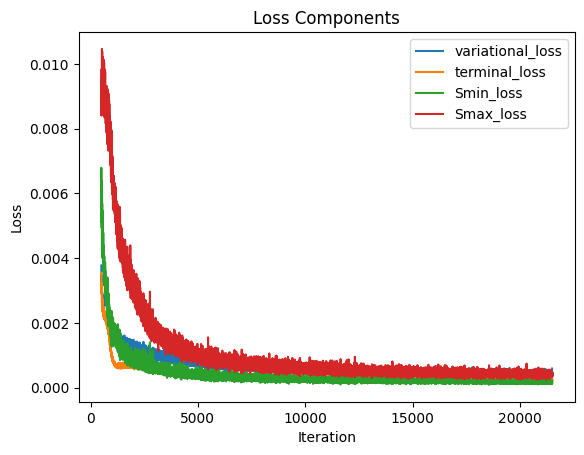

In [7]:
pinn.plot_losses(start_epoch=500, detailed=True)